In [1]:
using DirectTrajectoryOptimization
using LinearAlgebra
using CairoMakie

Setting up quantum optimal control problem for a single qubit with Hamiltonian given by

$$
H(a(t)) = H_{\text{drift}} + a(t) H_{\text{drive}}
$$ 

where $H_{\text{drift}} = \sigma_z$ and $H_{\text{drive}} = \sigma_x$.

We will also define the qubit basis kets (unit vectors in $\mathbb{C}^2$) $\ket{0}$ and $\ket{1}$.

In [49]:
X = [
    0 1;
    1 0
]

Y = [
    0 -im;
    im 0
]

Z = [
    1 0;
    0 -1
]

f = 0.5

H_drift = f * Z

H_drive = X

ψ0 = [1.0, 0.0]
ψ1 = [0.0, 1.0];


below will define the specific problem we will solve:

In [50]:
gate = X
ψi = ψ0
ψf = X * ψi

2-element Vector{Float64}:
 0.0
 1.0

Now we define the time-dependent Schroedinger equation dynamics:

$$
{d \over dt} \ket{\psi} = -i H \ket{\psi}
$$

Here we use the isomorphism $\mathbb{C}^2 \cong \mathbb{R}^4$ 

$$
\ket{\psi} \equiv \begin{pmatrix} \psi_0 \\ \psi_1 \end{pmatrix} \cong \begin{pmatrix} \psi_0^{\textrm{Re}} \\ \psi_0^{\textrm{Im}} \\ \psi_1^{\textrm{Re}} \\ \psi_1^{\textrm{Im}} \\ \end{pmatrix} \equiv \tilde \psi
$$

and for a matrix $H \in \mathbb{C}^{2 \times 2}$

$$
\tilde H = \begin{pmatrix} H^{\textrm{Re}} & -H^{\textrm{Im}} \\ H^{\textrm{Im}} & H^{\textrm{Re}} \end{pmatrix} 
= \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} \otimes H^{\textrm{Re}} + \begin{pmatrix} 0 & -1 \\ 1 & 0 \end{pmatrix} \otimes H^{\textrm{Im}}
$$

which implies that for a matrix in the form $-i H$
$$
G(H) \equiv \widetilde{\left( -i H \right)} = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} \otimes H^{\textrm{Im}} - \begin{pmatrix} 0 & -1 \\ 1 & 0 \end{pmatrix} \otimes H^{\textrm{Re}}
$$

In our case $G$ (named for the generator of time translation) can be written as

$$
G \equiv G(H(a(t))) = G(H_{\textrm{drift}}) + a(t)G(H_{\textrm{drive}})
$$

Now we can write the isomorphic dynamics equation:

$$
\begin{equation}
{d \over dt} \tilde \psi = G \ \tilde \psi
\end{equation}
$$

Let's now define functions to compute these isomorphisms, as well as get the real and imaginary parts of the Hamiltonian:

In [91]:
ket_to_iso(ψ) = [real(ψ)[1], imag(ψ)[1], real(ψ)[2], imag(ψ)[2]]
iso_to_ket(ψ̃) = [ψ̃[1] + im * ψ̃[2], ψ̃[3] + im * ψ̃[4]]

Id2 = I(2)
Im2 = [
    0 -1; 
    1  0
]

⊗(A, B) = kron(A, B)

G(H) = Id2 ⊗ imag(H) - Im2 ⊗ real(H) 

G_drift = G(H_drift)
G_drive = G(H_drive);

and define the dynamics:

In [92]:
schroedinger(x, u, w) = (G_drift + u[1] * G_drive) * x

schroedinger (generic function with 1 method)

In [93]:
h = 0.01

# general implicit midpoint method 
function midpoint_implicit(y, x, u, w)
    return y - (x + h * schroedinger(0.5 * (x + y), u, w))
end

# analytic solution of midpoint equation for schroedinger dynamics
function pade_schroedinger(y, x, u, w)
    G = G_drift + u[1] * G_drive
    return y - inv(I(4) - h / 2 * G) * (I(4) + h / 2 * G) * x
end

pade_schroedinger (generic function with 1 method)

now we will define the initial and final isomorphisms:

In [94]:
ψ̃i = ket_to_iso(ψi)
ψ̃f = ket_to_iso(ψf);

here we define the cost function (which is currently experimental):

$$
J(\tilde\psi, \tilde\psi_f) = \min\left( \left|1 - \braket{\psi | \psi_f}\right|, \left|1 + \braket{\psi | \psi_f}\right|\right)
$$

TODO: implement quaternionic cost function


In [95]:
function cost(ψ̃, ψ̃f)
    ψ = iso_to_ket(ψ̃)
    ψf = iso_to_ket(ψ̃f)
    return min(abs(1 - ψ'ψf), abs(1 + ψ'ψf))
end

costi(ψ̃) = ψ̃ - ψ̃i 
costf(ψ̃) = cost(ψ̃, ψ̃f)

costf (generic function with 1 method)

In [96]:
T = 1001
num_state = 4
num_action = 1
eval_hess=true;

In [97]:
dt = Dynamics(
    # pade_schroedinger,
    midpoint_implicit,
    num_state,
    num_state,
    num_action,
    evaluate_hessian=eval_hess
)
dynamics = [dt for t = 0:T-1];

In [98]:
ot = (x, u, w) -> costf(x) .+ 0.1 * dot(u, u)
oT = (x, u, w) -> costf(x)
ct = Cost(ot, num_state, num_action; evaluate_hessian=eval_hess)
cT = Cost(oT, num_state, num_action; evaluate_hessian=eval_hess)
objective = [[ct for t = 0:T-1]; cT];

In [99]:
bnd1 = Bound(num_state, num_action)
bndt = Bound(num_state, num_action)
bndT = Bound(num_state, 0)
bounds = [bnd1, [bndt for t = 1:T-1]..., bndT];

In [100]:
con1 = Constraint((x, u, w) -> costi(x), num_state, num_action, evaluate_hessian=eval_hess)
conT = Constraint((x, u, w) -> [costf(x)], num_state, num_action, evaluate_hessian=eval_hess) 
constraints = [con1; [Constraint() for t = 2:T-1]; conT];

In [109]:
solver = Solver(dynamics, objective, constraints, bounds);

In [111]:
# x_interpolation = linear_interpolation(ψ̃i, ψ̃f, T)
u_guess = [1.0 * randn(num_action) for t = 1:T-1];
# initialize_states!(solver, x_interpolation)
initialize_controls!(solver, u_guess)

In [112]:
solve!(solver);

This is Ipopt version 3.14.4, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:    28034
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     5009
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:     4009
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.0976669e+03 1.00e+00 1.00e+00   0.0 0.00e+00    -  0.00e+00 0.00e+00  

In [113]:
x_traj, u_traj = get_trajectory(solver);

In [114]:
@show x_traj[end]

x_traj[end] = [0.008883222623793565, -0.0001531688046520682, 0.9999637779424554, -5.735073433292378e-7]


4-element Vector{Float64}:
  0.008883222623793565
 -0.0001531688046520682
  0.9999637779424554
 -5.735073433292378e-7

In [115]:
u_traj[1]

1-element Vector{Float64}:
 -0.1448794369838323

In [116]:
function plot_wfn(X, U)
    ψs = hcat(X...)
    fig = Figure(resolution=(1200, 500))
    ax, _ = series(fig[1,1], ψs, labels=[L"\psi_0^R", L"\psi_0^I", L"\psi_1^R", L"\psi_1^I"])
    axislegend(ax)
    us = vec(hcat(U...))
    ax, _ = lines(fig[1,2], 0:T-1, us, label=L"u(t)")
    axislegend(ax)
    return fig
end

plot_wfn (generic function with 1 method)

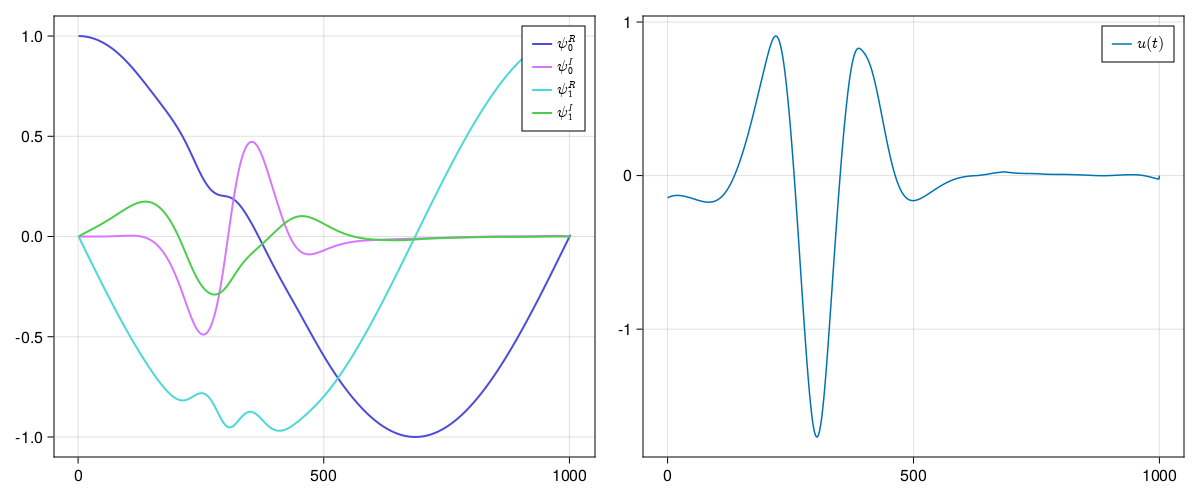

In [117]:
plot_wfn(x_traj, u_traj)